In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

In [2]:
TICKERS =  ["AAPL", "NVDA"]

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR  = REPO_ROOT / "data" / "raw"
OUT_DIR   = REPO_ROOT / "data" / "processed"
FIG_DIR   = REPO_ROOT / "reports" / "figures"

COLORS = {
    "AAPL": "#1f77b4",   # blue
    "NVDA": "#2ca02c",   # green
}

In [3]:
def load_stock(ticker: str) -> pd.DataFrame:
    path = DATA_DIR / f"{ticker}_data.csv"
    return pd.read_csv(path, index_col="Date", parse_dates=True)

stock_data = {ticker: load_stock(ticker) for ticker in TICKERS}

stock_data["AAPL"].head()

,Open,High,Low,Close,Volume,Daily_Return,MA_20,MA_50,Volatility_20
Date,,,,,,,,,
2021-01-04,129.734330,129.821775,123.165994,125.740860,143301900,NaN,NaN,NaN,NaN
2021-01-05,125.235592,128.004792,124.788628,127.295479,97664900,0.012364,NaN,NaN,NaN
2021-01-06,124.098745,127.334331,122.796735,123.010498,155088000,-0.033662,NaN,NaN,NaN
2021-01-07,124.720594,127.897884,124.234771,127.208008,109578200,0.034123,NaN,NaN,NaN
2021-01-08,128.675231,128.869572,126.537610,128.306015,105158200,0.008632,NaN,NaN,NaN


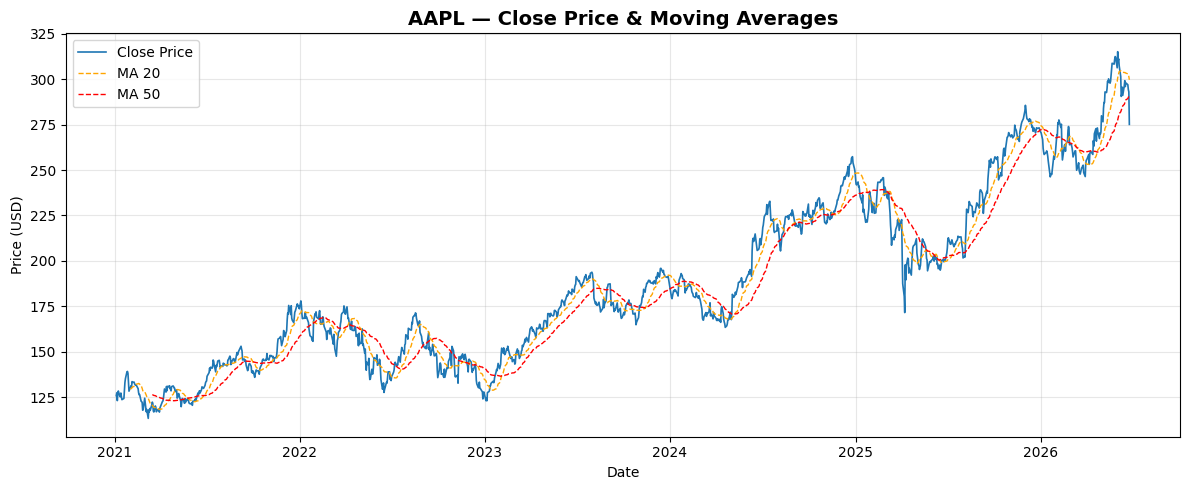

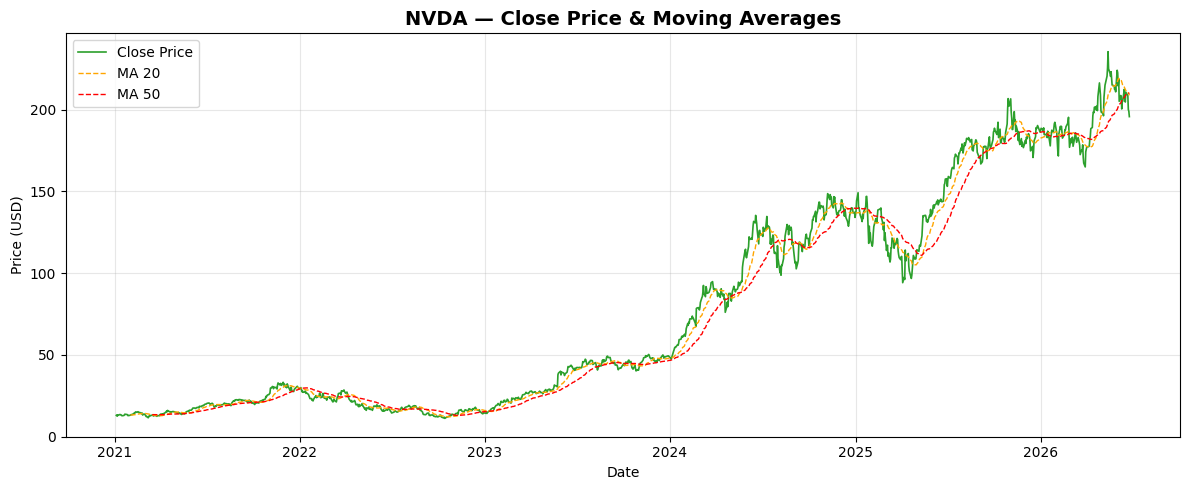

In [4]:
def plot_price_ma(ticker: str, df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 5))
    color = COLORS[ticker]
 
    ax.plot(df.index, df["Close"],  color=color,   linewidth=1.2, label="Close Price")
    ax.plot(df.index, df["MA_20"],  color="orange", linewidth=1,   linestyle="--", label="MA 20")
    ax.plot(df.index, df["MA_50"],  color="red",    linewidth=1,   linestyle="--", label="MA 50")
 
    ax.set_title(f"{ticker} — Close Price & Moving Averages", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
 

for ticker, df in stock_data.items():
    plot_price_ma(ticker, df)

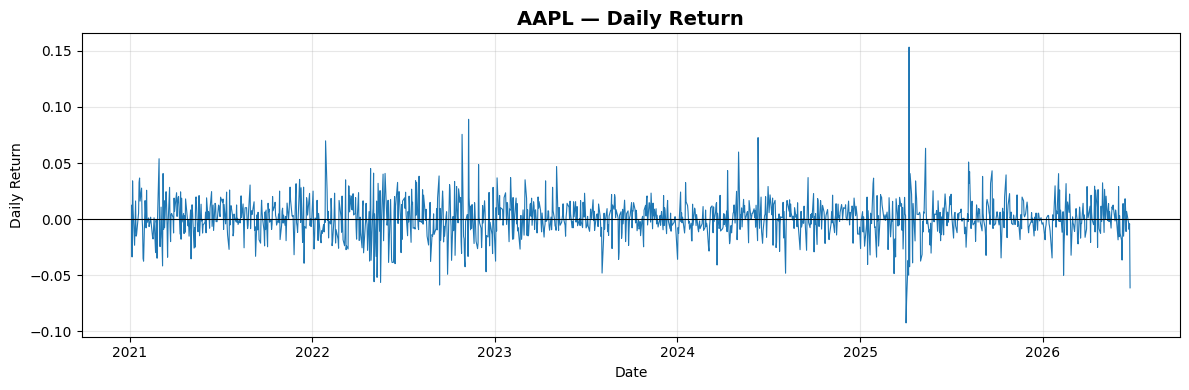

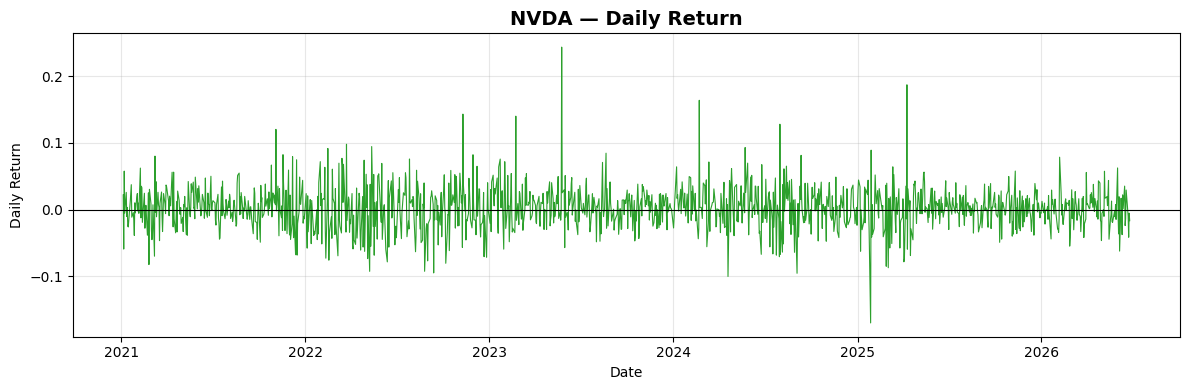

In [5]:
def plot_daily_return(ticker: str, df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 4))
    color = COLORS[ticker]

    ax.plot(df.index, df["Daily_Return"], color=color, linewidth=0.8)

    ax.set_title(f"{ticker} — Daily Return", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily Return")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)
    fig.tight_layout()


for ticker, df in stock_data.items():
    plot_daily_return(ticker, df)

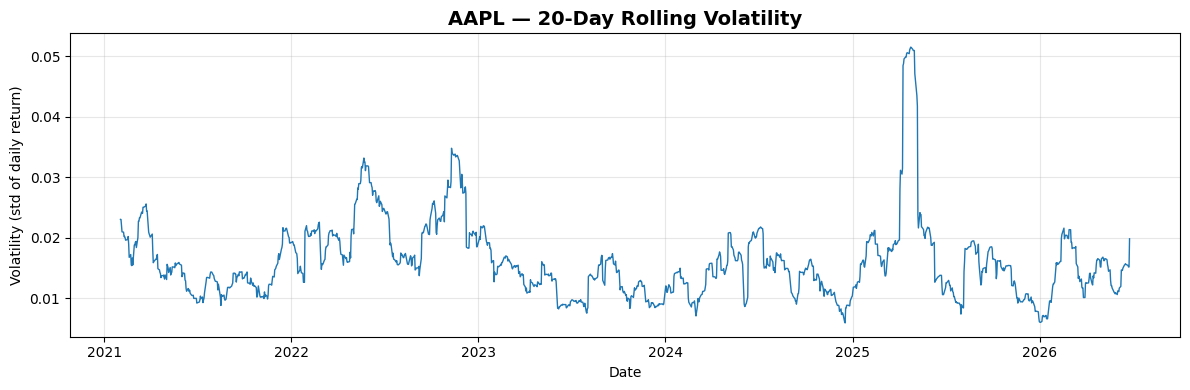

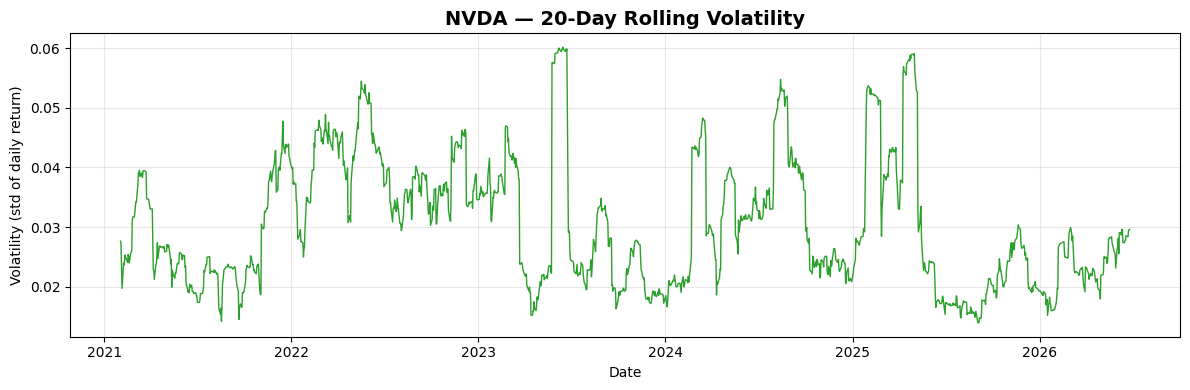

In [6]:
def plot_volatility(ticker: str, df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 4))
    color = COLORS[ticker]

    ax.plot(df.index, df["Volatility_20"], color=color, linewidth=1)

    ax.set_title(f"{ticker} — 20-Day Rolling Volatility", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Volatility (std of daily return)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)
    fig.tight_layout()


for ticker, df in stock_data.items():
    plot_volatility(ticker, df)

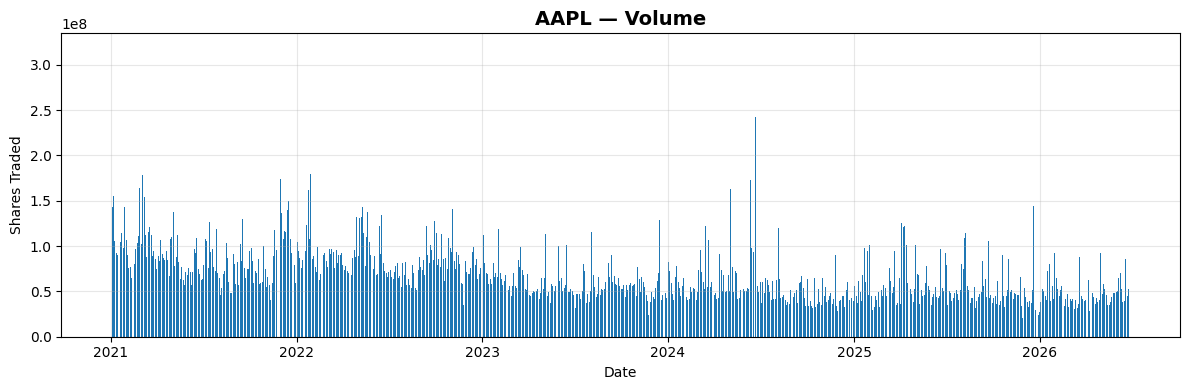

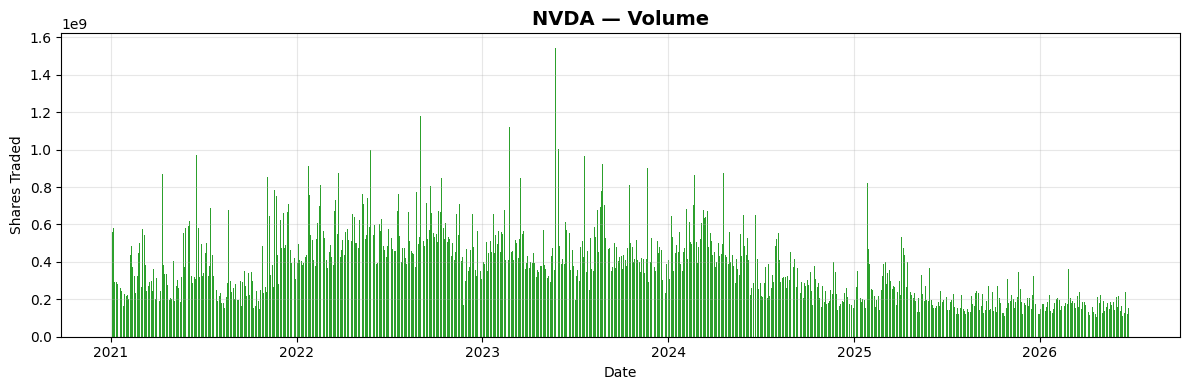

In [7]:
def plot_volume(ticker: str, df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 4))
    color = COLORS[ticker]

    ax.bar(df.index, df["Volume"], color=color, width=1.0)

    ax.set_title(f"{ticker} — Volume", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Shares Traded")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)
    fig.tight_layout()


for ticker, df in stock_data.items():
    plot_volume(ticker, df)

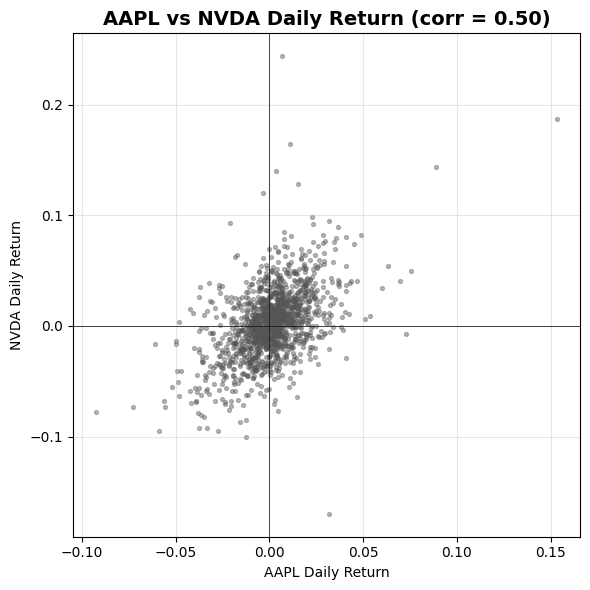

In [8]:
returns = pd.DataFrame({ticker: df["Daily_Return"] for ticker, df in stock_data.items()}).dropna()
corr = returns["AAPL"].corr(returns["NVDA"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(returns["AAPL"], returns["NVDA"], s=8, alpha=0.4, color="#555555")

ax.set_title(f"AAPL vs NVDA Daily Return (corr = {corr:.2f})", fontsize=14, fontweight="bold")
ax.set_xlabel("AAPL Daily Return")
ax.set_ylabel("NVDA Daily Return")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3)
fig.tight_layout()

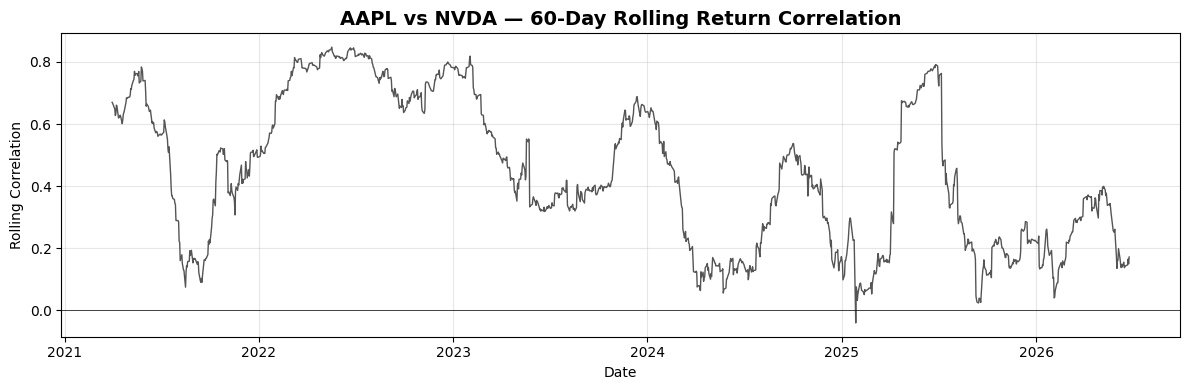

In [9]:
rolling_corr = returns["AAPL"].rolling(60).corr(returns["NVDA"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_corr.index, rolling_corr, color="#555555", linewidth=1)

ax.set_title("AAPL vs NVDA — 60-Day Rolling Return Correlation", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Correlation")
ax.axhline(0, color="black", linewidth=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, alpha=0.3)
fig.tight_layout()

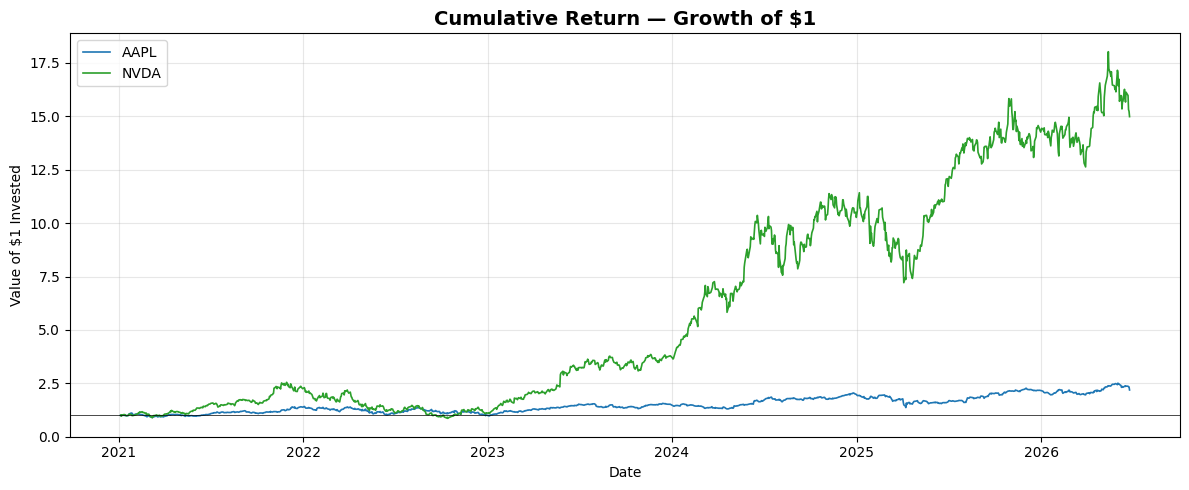

In [10]:
def plot_cumulative_return(ticker: str, df: pd.DataFrame, ax):
    color = COLORS[ticker]
    cum_return = (1 + df["Daily_Return"].fillna(0)).cumprod()
    ax.plot(df.index, cum_return, color=color, linewidth=1.2, label=ticker)


fig, ax = plt.subplots(figsize=(12, 5))
for ticker, df in stock_data.items():
    plot_cumulative_return(ticker, df, ax)

ax.set_title("Cumulative Return — Growth of $1", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Value of $1 Invested")
ax.axhline(1, color="black", linewidth=0.5)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, alpha=0.3)
fig.tight_layout()

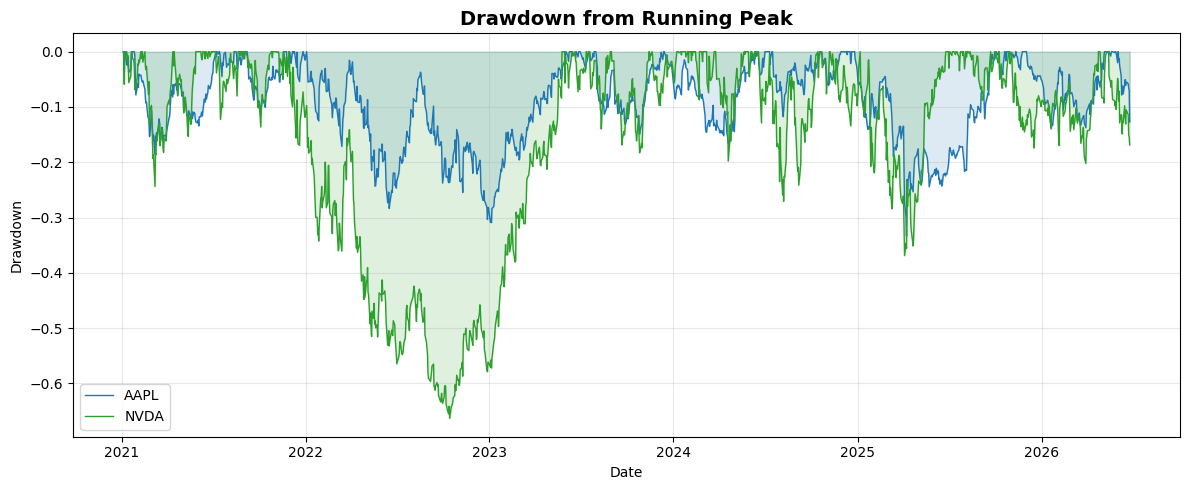

In [11]:
def compute_drawdown(df: pd.DataFrame) -> pd.Series:
    running_max = df["Close"].cummax()
    return (df["Close"] - running_max) / running_max


fig, ax = plt.subplots(figsize=(12, 5))
for ticker, df in stock_data.items():
    drawdown = compute_drawdown(df)
    color = COLORS[ticker]
    ax.plot(df.index, drawdown, color=color, linewidth=1, label=ticker)
    ax.fill_between(df.index, drawdown, 0, color=color, alpha=0.15)

ax.set_title("Drawdown from Running Peak", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, alpha=0.3)
fig.tight_layout()

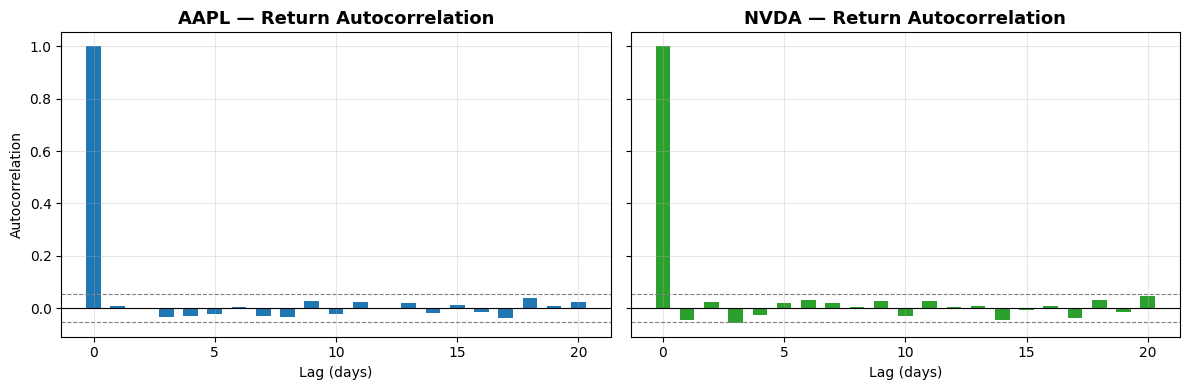

In [12]:
import numpy as np

def acf(series: pd.Series, n_lags: int) -> np.ndarray:
    x = series.dropna().values
    x = x - x.mean()
    denom = (x ** 2).sum()
    return np.array([1.0 if lag == 0 else (x[:-lag] * x[lag:]).sum() / denom for lag in range(n_lags + 1)])


N_LAGS = 20
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (ticker, df) in zip(axes, stock_data.items()):
    values = acf(df["Daily_Return"], N_LAGS)
    conf = 1.96 / np.sqrt(df["Daily_Return"].dropna().shape[0])

    ax.bar(range(N_LAGS + 1), values, color=COLORS[ticker], width=0.6)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(conf, color="gray", linewidth=0.8, linestyle="--")
    ax.axhline(-conf, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(f"{ticker} — Return Autocorrelation", fontsize=13, fontweight="bold")
    ax.set_xlabel("Lag (days)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Autocorrelation")
fig.tight_layout()

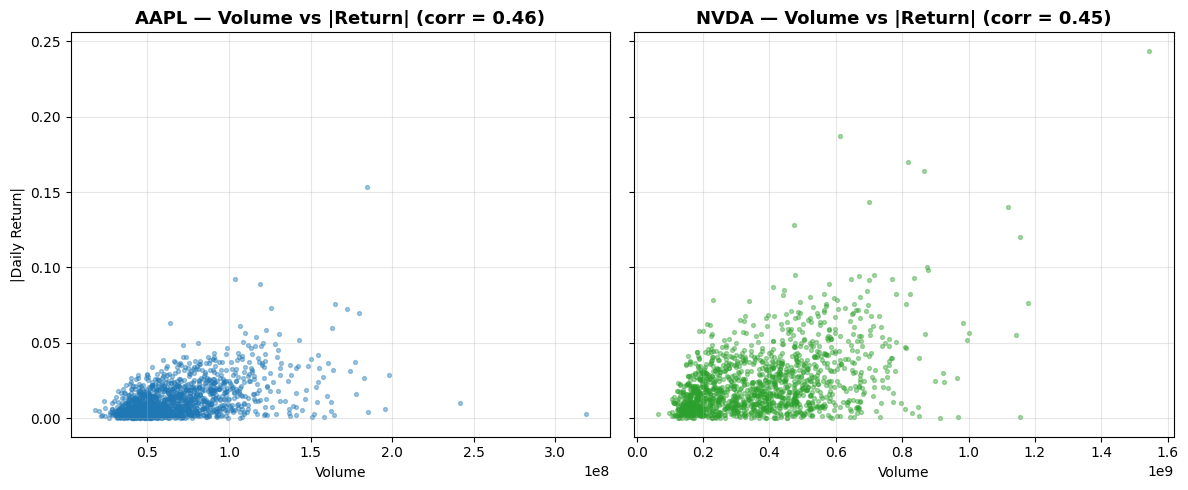

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (ticker, df) in zip(axes, stock_data.items()):
    abs_return = df["Daily_Return"].abs()
    ax.scatter(df["Volume"], abs_return, s=8, alpha=0.4, color=COLORS[ticker])

    corr = df["Volume"].corr(abs_return)
    ax.set_title(f"{ticker} — Volume vs |Return| (corr = {corr:.2f})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Volume")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("|Daily Return|")
fig.tight_layout()